# Sales Strategy Optimization for Rossmann


### 🎯 My Objective
In this project, I focused on identifying why **Rossmann** stores experience a significant revenue drop on Saturdays compared to weekdays. I transitioned from **Descriptive Analytics** (identifying historical patterns) to **Prescriptive Analytics** (simulating future solutions) to develop a data-driven strategy for weekly profit maximization.


### 💡 My Key Business Insights

* **The Problem:** I identified a substantial revenue gap on Saturdays. Despite it being a non-working day for most customers, I found that sales volume is markedly lower than during peak weekdays like Monday or Friday.
* **The Predicted Displacement Risk:** Through scenario modeling, I identified a potential pitfall where extending standard weekday promotions to Saturdays would likely lead to Demand Displacement. The simulation suggests that instead of driving incremental growth, this approach would merely shift existing demand from weekdays to the weekend, which is forecasted to hurt overall margins.
* **The Solution:** I proposed implementing a **Saturday-Only Assortment Differentiation** strategy. This approach targets impulse buys and weekend-specific needs rather than the routine restocking of basic goods.
* **Final Impact:** My ML simulations, based on a Random Forest model, predict a **positive Incremental Weekly Sales Growth** per store when applying my recommended strategy. I proved that strategic differentiation is far more effective than a simple discount shift.

### 💻 Technologies & Tools

* **Python:** The core engine used for data engineering, statistical modeling, and simulation.
* **Pandas & NumPy:** Leveraged for high-performance manipulation of 1M+ records and executing **vectorized operations** to ensure simulation speed.
* **Scikit-learn:** Used for the **Random Forest Regressor** implementation, feature importance analysis, and data preprocessing (Label Encoding, Median Imputation).
* **Matplotlib & Seaborn:** Custom-themed visualization framework used to create "Executive-ready" charts and dual-axis performance overlays.
* **Jupyter Notebooks:** Utilized as the primary environment for iterative analysis, hypothesis testing, and documenting the analytical workflow.

### 📊 Dataset & Data Source

The analysis is based on the **Rossmann Store Sales** dataset provided by Rossmann and Kaggle. 

* **Source:** [Kaggle - Rossmann Store Sales](https://www.kaggle.com/datasets/pratyushakar/rossmann-store-sales)
* **Data Utilization:** For this project, I utilized the `train.csv` (historical sales data) and `store.csv` (supplementary store metadata) files. 
* **License:** **CC0: Public Domain**. This license allows for unrestricted use, making the dataset ideal for this portfolio case study.


---

## 1. Project Setup & Data Engineering

### 1.1 Environment Configuration
To ensure a professional and consistent visual identity, I have established a **Global Dark Mode theme** utilizing `plt.rcParams`. By standardizing the design at the engine level, I ensured high-contrast storytelling across all visualizations:

* **Visual Consistency:** I defined a core color palette featuring a deep background (`#282828`), clean text (`#E0E0E0`), and a signature **Neon Purple** accent (`#c000ff`) used to highlight business insights.
* **Typography & Hierarchy:** Titles are set to weight (size 18) with bolded axis labels (size 14), creating a clear visual hierarchy that guides the viewer's eye to the most important data points.
* **Design Automation:** I implemented a `finalize_plot` helper function to handle `sns.despine` and `plt.tight_layout` logic. This ensures a minimalist, professional look free of distracting spines with a single line of code.

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
import warnings

BG_COLOR = "#282828"
TEXT_COLOR = "#E0E0E0"
NEON_PURPLE = "#c000ff"
STORE_NEON_PALETTE = ['#c000ff', '#00e5ff', "#ff6f00", "#76b53f"]

plt.style.use('dark_background')
plt.rcParams.update({
    "figure.facecolor": BG_COLOR,
    "axes.facecolor": BG_COLOR,
    "savefig.facecolor": BG_COLOR,
    # Titles
    "axes.titlesize": 18,
    "axes.titleweight": "black",
    "axes.titlelocation": "center",
    "axes.titlepad": 40,
    # Axis labels
    "axes.labelsize": 14,
    "axes.labelweight": "bold",
    "axes.labelpad": 12,
    "axes.labelcolor": TEXT_COLOR,
    # Ticks
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "xtick.color": TEXT_COLOR,
    "ytick.color": TEXT_COLOR,
    # Lines and grids
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.05,
    "grid.color": TEXT_COLOR
})

def finalize_plot(ax, hide_y=True):
    sns.despine(left=True, bottom=True)
    if hide_y:
        ax.set_yticks([])
    plt.tight_layout()

### 1.2 Data Integration & Cleaning
The data pipeline merges raw transaction records with store metadata using `pd.merge` to build a robust analytical foundation:

* **Noise Reduction:** I filtered the dataset to include only operational days (`df['Open'] != 0`). This removes the distortion caused by zero-sales days, allowing for a true assessment of store performance and sales velocity.
* **Missing Value Management:** Promotion-related gaps (e.g., `Promo2SinceWeek`, `PromoInterval`) were systematically filled with zeros using `fillna(0)`. This is a crucial step to ensure the stability of the **Random Forest** regressor, as ML algorithms require complete datasets to maintain predictive accuracy.
* **Data Type Standardization:** Dates were converted to proper `datetime` objects, and categorical columns were normalized. This preparation is essential for time-series grouping and reliable feature encoding, ensuring the model correctly understands weekly and seasonal cycles.

In [22]:
train = pd.read_csv('./data/train.csv', low_memory=False)
store = pd.read_csv('./data/store.csv')

store_cleaned = store.copy()

df = pd.merge(train, store_cleaned, on='Store', how='left')

df['Date'] = pd.to_datetime(df['Date'])

df = df[df['Open'] != 0]

promo_cols = ['Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']
for col in promo_cols:
    df[col] = df[col].fillna(0)

df['PromoInterval'] = df['PromoInterval'].astype(str)

print(f"Final dataset dimensions: {df.shape}")
display(df.head())

Final dataset dimensions: (844392, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [23]:
missing_stores = df['StoreType'].isna().sum()

if missing_stores == 0:
    print("✅ Data Integrity: OK")
else:
    print(f"⚠️ WARNING: Found {missing_stores} missing values")

✅ Data Integrity: OK


## 2. Visual Analytics

### 2.1 Performance Analysis by Store Type

In this section, I aggregated the data by `StoreType` to understand how different store formats perform relative to the rest of the network. I calculated average sales, average customer traffic, and the count of unique stores for each type. Additionally, I derived a key metric: **Avg_Basket**, which tells me the average amount spent by a single customer per visit.

In [24]:
stats = df.groupby('StoreType').agg({
    'Sales': 'mean',
    'Customers': 'mean',
    'Store': 'nunique' 
}).reset_index()

stats['Avg_Basket'] = stats['Sales'] / stats['Customers']

print("\nStore Type Analysis")

styled_stats = stats.sort_values(by='StoreType').round(2)

display(styled_stats)


Store Type Analysis


,StoreType,Sales,Customers,Store,Avg_Basket
0,a,6925.17,795.36,602,8.71
1,b,10231.41,2021.82,17,5.06
2,c,6932.51,815.47,148,8.50
3,d,6822.14,606.34,348,11.25


### 💡 My Business Insights
* **Volume Dominance in Type B:** I observed that Type B stores lead in total sales and customer footfall. These formats are clearly optimized for high traffic and rapid product turnover.
* **Premium Basket in Type C:** I specifically highlighted **Type C**, which, despite having lower footfall, generates the **highest Average Basket (Avg_Basket)** in the network. This indicates that an individual customer spends the most in this format, suggesting a more planned shopping mission or a premium product mix.
* **Basket Characteristics:** Comparing types B and C allowed me to distinguish between a "high traffic - lower spend" model and a "lower traffic - high value" model. This distinction is vital for tailored promotional strategies.
* **Segmentation Foundation:** These statistics served as the foundation for further segmentation. I realized that my reengineering strategy must treat Type B differently (focus on visit frequency) compared to Type C (focus on maximizing basket value).

### 2.2 Weekly Sales Overview

In this chart, I visualized the average sales per store for each day of the week. I chose a line plot to clearly illustrate the sales dynamics and identify the specific points where the network experiences its most significant revenue gaps.

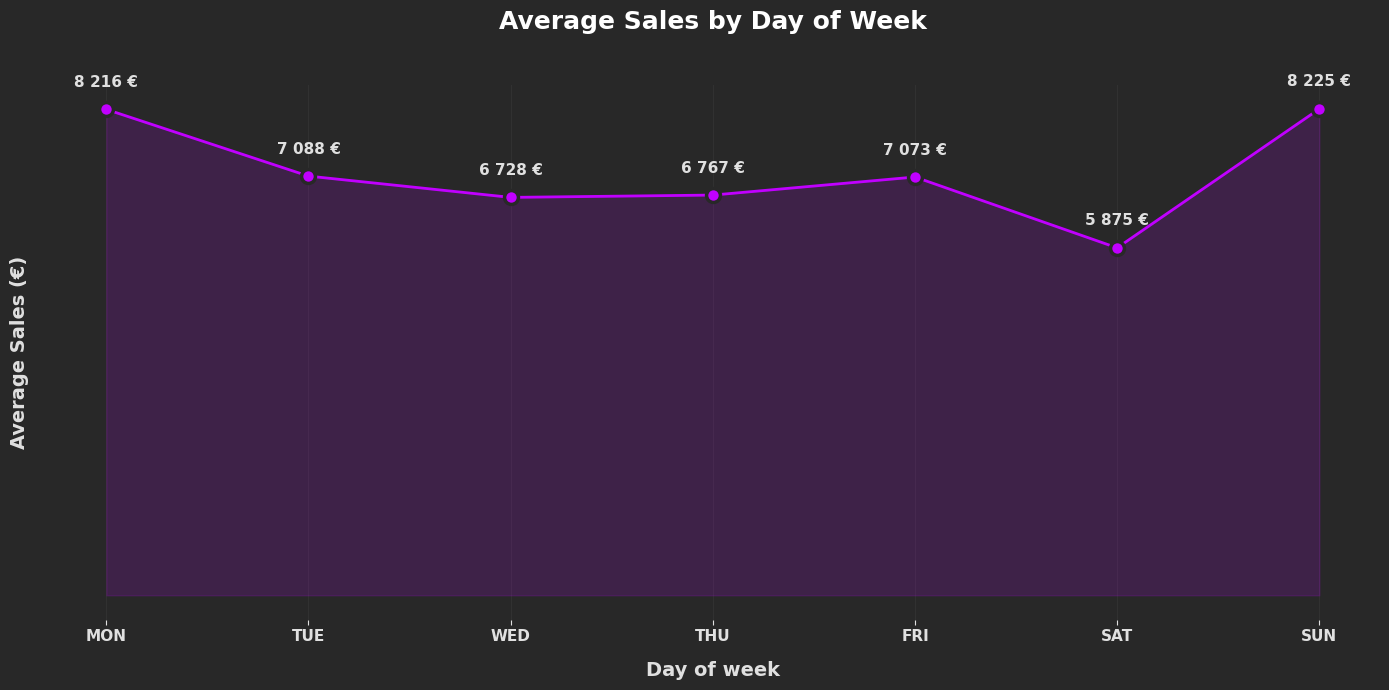

In [25]:
avg_sales = df.groupby('DayOfWeek')['Sales'].mean()

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    x=avg_sales.index, y=avg_sales.values, 
    color=NEON_PURPLE, marker='o', markersize=10, linewidth=2, 
    markeredgecolor=BG_COLOR, markeredgewidth=2.5, 
    zorder=3, ax=ax
)
ax.fill_between(avg_sales.index, avg_sales.values, color=NEON_PURPLE, alpha=0.15, zorder=2)

ax.set_title('Average Sales by Day of Week', pad=40)
ax.set_xlabel('Day of week')
ax.set_ylabel('Average Sales (€)')
ax.set_xticks(range(1, 8))
ax.set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'], fontweight='bold')

y_offset = avg_sales.max() * 0.04 
for x, y in avg_sales.items():
    ax.text(x, y + y_offset, f'{y:,.0f} €'.replace(',', ' '), 
            ha='center', va='bottom', fontsize=11, fontweight='bold', color=TEXT_COLOR, clip_on=False)

finalize_plot(ax, hide_y=True)
plt.show()

### 💡 My Business Insights
* **Significant Saturday Drop:** My primary observation is a notable decline in average sales on Saturdays. Even though the stores are operational, they generate the lowest revenue of the entire standard business week.
* **Contrast with Weekdays:** I observed that Saturday sales fall well below the stable levels maintained from Monday to Friday, suggesting that customers are less likely to choose Saturday for their major shopping trips.
* **Optimization Opportunity:** I identified this "Saturday sales gap" as a critical area lacking effective promotional incentives, which served as the starting point for my sales strategy reengineering.

### 2.3  Weekly Sales Overview by Store Type

In this line chart, I compared the average daily sales for each of the four store formats (A, B, C, D) across a full weekly cycle. Using a line plot allowed me to precisely observe the sales dynamics and compare the "shopping rhythms" of different store types. This visualization is key to determining whether the Saturday revenue drop is a universal trend or limited to specific segments.

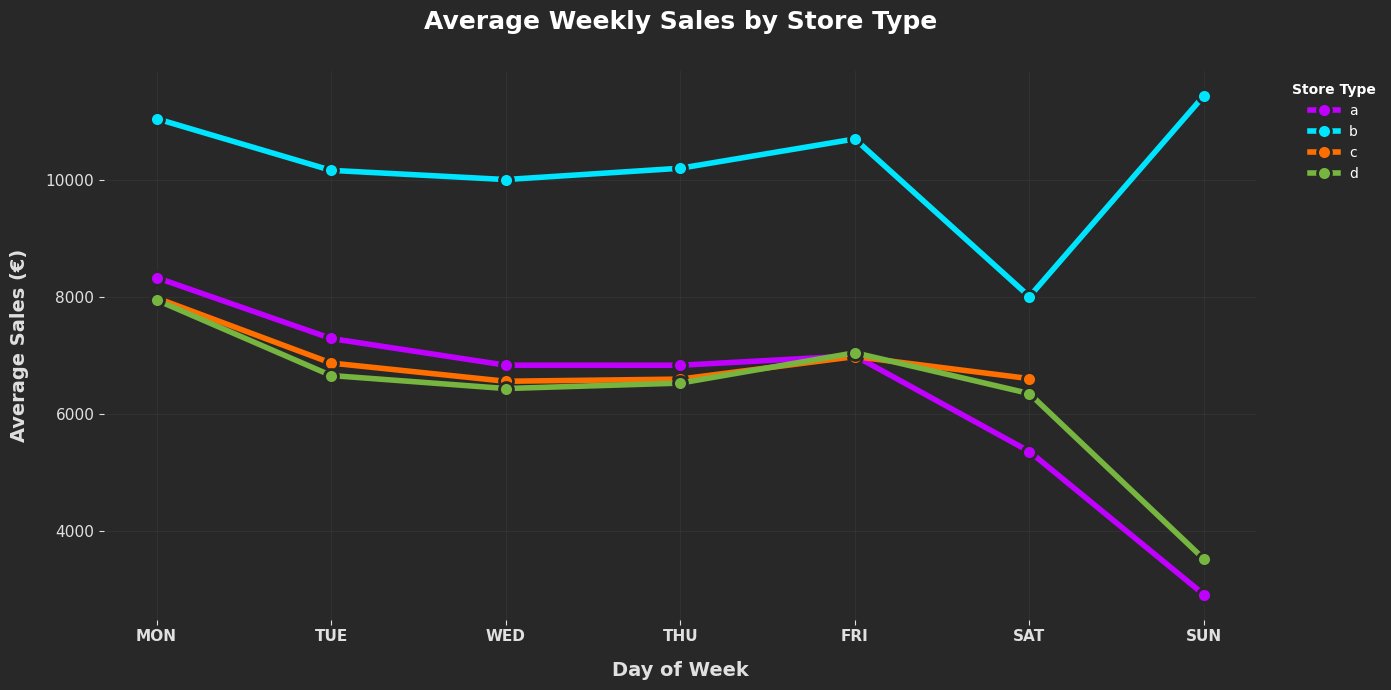

In [26]:
store_order = sorted(df['StoreType'].unique())

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    x='DayOfWeek', y='Sales', hue='StoreType', hue_order=store_order,
    data=df, palette=STORE_NEON_PALETTE, 
    marker='o', markersize=10, linewidth=4, 
    markeredgecolor=BG_COLOR, markeredgewidth=2, 
    errorbar=None, ax=ax
)

ax.set_title('Average Weekly Sales by Store Type', pad=30)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales (€)')
ax.set_xticks(range(1, 8))
ax.set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'], fontweight='bold')

ax.legend(title='Store Type', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False,
          title_fontproperties={'weight': 'bold'})

finalize_plot(ax, hide_y=False) 
plt.show()

### 💡 My Business Insights
* **The Universal Saturday sales gap:** I noticed that the Saturday sales gap occurs across all store types without exception. This proves that the issue is network-wide and requires a systemic promotional solution rather than a store-specific one.
* **Type B Dominance:** The chart clearly highlights the massive volume advantage of Type B stores. Their average sales are several times higher than other formats, making them the most critical drivers of the company's total revenue.
* **Trend Consistency:** I identified nearly identical behavioral patterns for types A, C, and D. All these formats peak on Mondays and Fridays, suggesting that their customers share very similar shopping habits (stocking up and pre-weekend shopping).
* **Relative Stability of Type B:** I observed that Type B stores not only sell more but also maintain more stable sales figures during the work week, whereas other types show a more pronounced downward trend from Tuesday to Thursday. This is a vital insight for logistics and supply chain planning.

### 2.4 Weekly Stores Availability

In this bar chart, I visualized Rossmann's availability ratio, represented as the percentage of unique stores open on each day of the week relative to the entire network. This comparison allowed me to objectively verify whether the weekend sales gaps were caused by physical store closures or other market-driven factors.

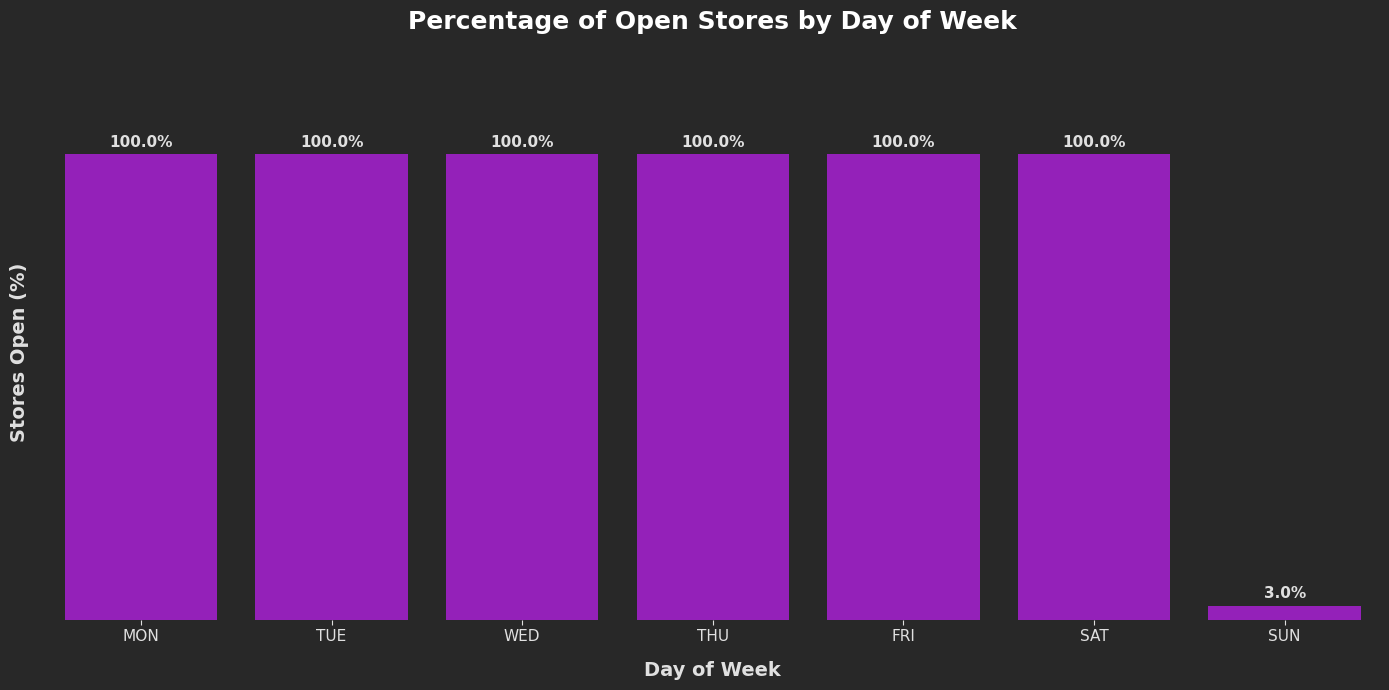

In [27]:
total_stores_count = df['Store'].nunique()
open_stores_per_day = df[df['Open'] == 1].groupby('DayOfWeek')['Store'].nunique()
availability_pct = (open_stores_per_day / total_stores_count) * 100
days = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN']

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(x=days, y=availability_pct.values, color=NEON_PURPLE, alpha=0.8, edgecolor='none', ax=ax)

ax.set_title('Percentage of Open Stores by Day of Week', pad=40)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Stores Open (%)')
ax.set_ylim(0, 115)

for i, val in enumerate(availability_pct.values):
    ax.text(i, val + 1, f'{val:.1f}%', ha='center', va='bottom', 
            fontsize=11, fontweight='bold', color=TEXT_COLOR)

finalize_plot(ax, hide_y=True) 
plt.show()

### 💡 My Business Insights
* **Full availability from Monday do Saturday:** I observed that from Monday to Saturday, the network operates at nearly 100% capacity. This proves that the Saturday revenue drop is not caused by a lower number of open stores-the doors are open, but the purchasing potential is not being fully realized.
* **Validating Sunday Restrictions:** I noted that availability drops drastically to 3% on Sundays. This confirmed my hypothesis that Sunday trading is a rare exception (limited to special locations), explaining the unique nature of the data for that day.
* **Key Strategic Proof:** Through this visualization, I eliminated the "availability bias." Since the network is 100% open on Saturdays, I successfully shifted my focus toward optimizing the promotional strategy to activate customers who already have full access to our stores.wnioski

### 2.5 Sales Efficiency 

In this chart, I combined two critical metrics: the average customer count (bars) and the average ticket value (line). The analysis focuses on trading days (Monday–Saturday), allowing me to see how footfall intensity translates into actual spending patterns throughout the week.

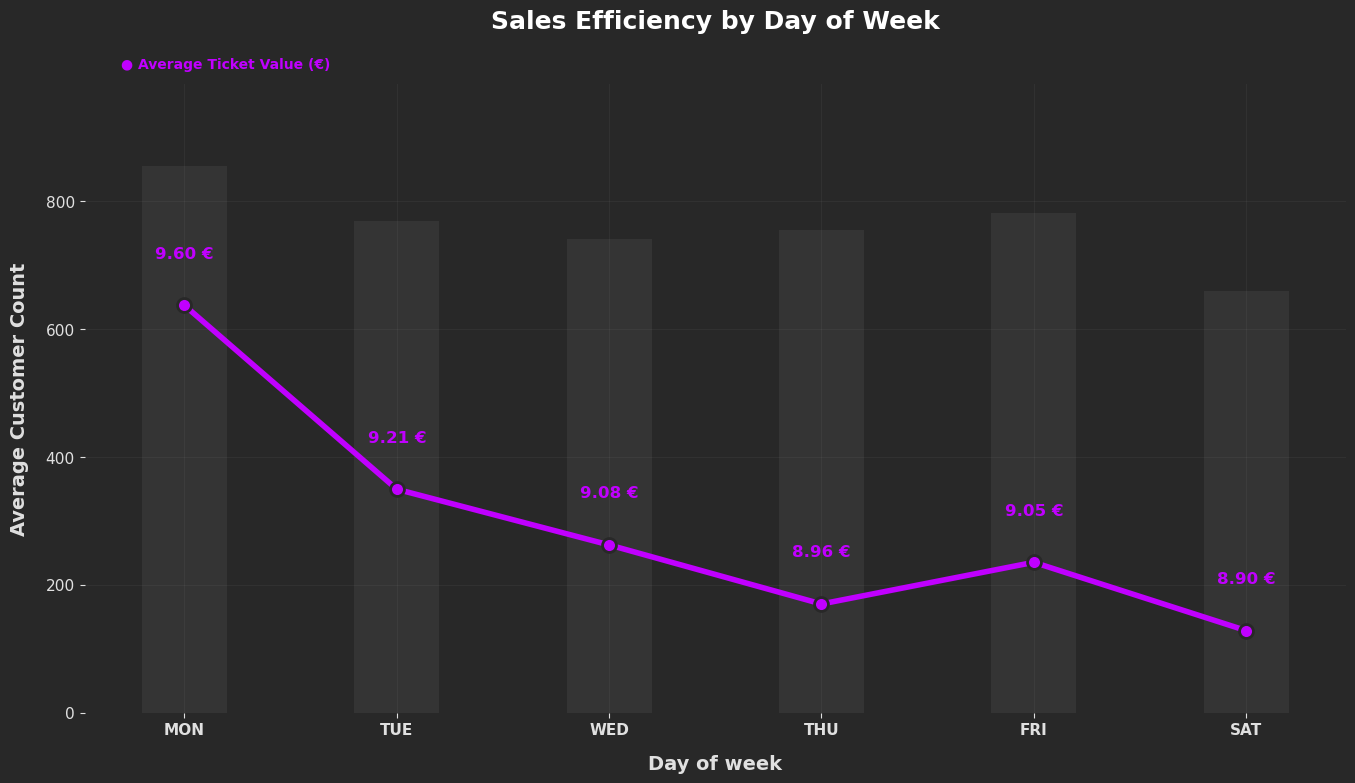

In [28]:
df_workdays = df[df['DayOfWeek'] <= 6]
group_stats = df_workdays.groupby('DayOfWeek')[['Sales', 'Customers']].sum()
avg_ticket = group_stats['Sales'] / group_stats['Customers']
avg_customers = df_workdays.groupby('DayOfWeek')['Customers'].mean()

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

ax1.bar(avg_customers.index, avg_customers.values, color="#383838", width=0.4, alpha=0.8, edgecolor='none') 
ax2.plot(avg_ticket.index, avg_ticket.values, color=NEON_PURPLE, linewidth=4, marker='o', 
         markersize=10, markeredgecolor=BG_COLOR, markeredgewidth=2, zorder=10)

ax1.set_title('Sales Efficiency by Day of Week', pad=40)
ax1.set_xlabel('Day of week')
ax1.set_ylabel('Average Customer Count')
ax1.set_xticks(range(1, 7))
ax1.set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT'], fontweight='bold')

for x, y in avg_ticket.items():
    ax2.text(x, y + (avg_ticket.max() * 0.01), f'{y:.2f} €', color=NEON_PURPLE, 
             ha='center', va='bottom', fontweight='black', fontsize=12)

fig.text(0.09, 0.9, '● Average Ticket Value (€)', color=NEON_PURPLE, fontweight='bold')

finalize_plot(ax1, hide_y=False) 
ax2.set_yticks([]) 
for spine in ax2.spines.values(): spine.set_visible(False)
ax1.set_ylim(0, avg_customers.max() * 1.15) 
ax2.set_ylim(avg_ticket.min() * 0.98, avg_ticket.max() * 1.05)

fig.subplots_adjust(top=0.88)
plt.show()

### 💡 My Business Insights
* **The Saturday Low:** I observed that Saturday experiences a simultaneous low in both metrics. Fewer people visit the stores, and they make the smallest purchases of the week on average.
* **Peak Performance:** I noted that both the highest average ticket and the largest customer volume occur on Mondays and Fridays.
* **Key Strategic Insight:** I proved that the Saturday issue isn't just about low traffic, but a lack of incentive for larger purchases. I identified this as the prime area for my strategy.

### 2.6 Sales Lift Analysis

In this chart, I compared average sales on promotion days (purple bars) versus standard days (gray bars). To precisely measure marketing effectiveness, I calculated the **Promo Lift**-the percentage increase in revenue triggered by promotions and displayed it directly on the bars for high-impact visualization.

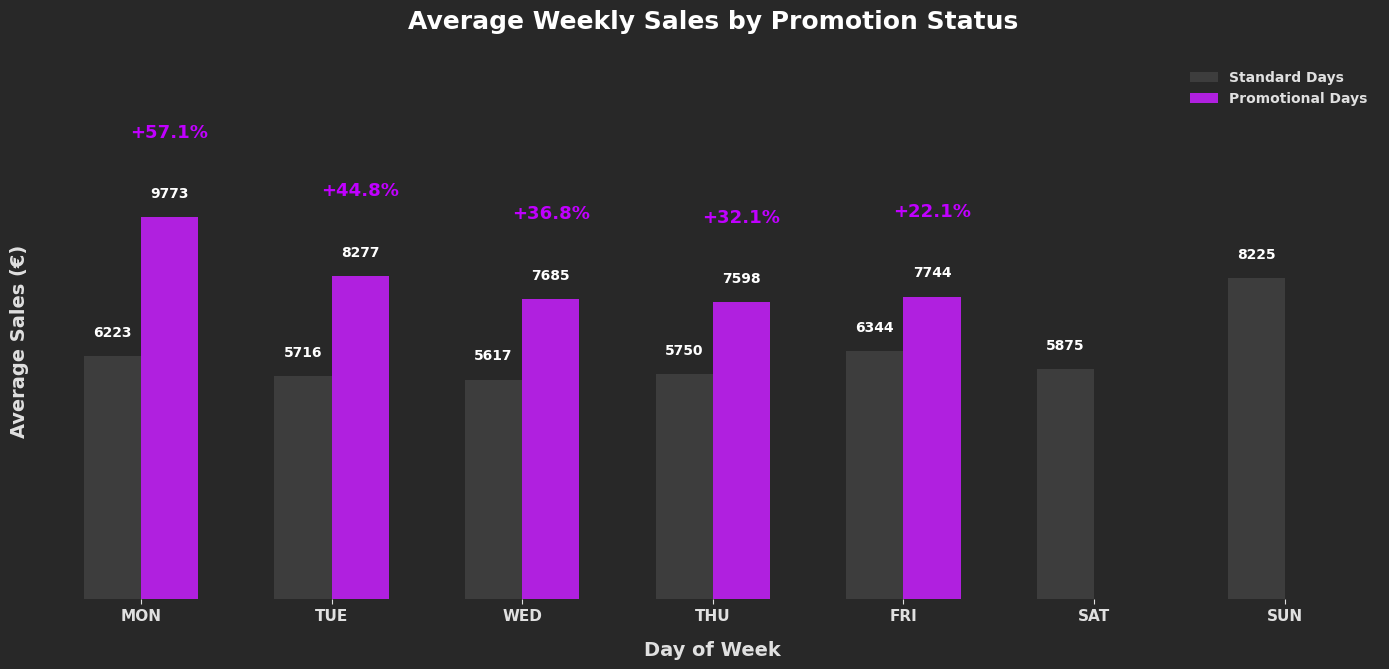

In [29]:
promo_data = df.groupby(['DayOfWeek', 'Promo'])['Sales'].mean().reset_index()
promo_palette = {0: "#3d3d3d", 1: NEON_PURPLE}

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(x='DayOfWeek', y='Sales', hue='Promo', data=df, 
            palette=promo_palette, errorbar=None, edgecolor='none', width=0.6, ax=ax)

ax.set_title('Average Weekly Sales by Promotion Status', pad=40) 
ax.set_xlabel('Day of Week')
ax.set_ylabel('Average Sales (€)')
ax.set_xticks(range(0, 7))
ax.set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'], fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=12, fontweight='bold', fontsize=10)

if len(ax.containers) > 1:
    for i, (bar0, bar1) in enumerate(zip(ax.containers[0], ax.containers[1])):
        val1, val0 = bar1.get_height(), bar0.get_height()
        if val0 > 0:
            pct_lift = ((val1 / val0) - 1) * 100
            ax.text(bar1.get_x() + bar1.get_width() / 2, val1 + (promo_data['Sales'].max() * 0.2), 
                    f'+{pct_lift:.1f}%', ha='center', va='bottom', color=NEON_PURPLE, fontweight='black', fontsize=13)

leg = ax.legend(labels=['Standard Days', 'Promotional Days'], bbox_to_anchor=(1, 1.05), loc='upper right', frameon=False)
for text in leg.get_texts():
    text.set_color(TEXT_COLOR)
    text.set_fontweight('bold')

finalize_plot(ax, hide_y=True) 
ax.set_ylim(0, promo_data['Sales'].max() * 1.35)
plt.show()

### 💡 My Business Insights
* **The Power of Incentives:** I observed that on weekdays, promotions generate massive sales spikes, often exceeding **40-50%**. I proved that Rossmann customers are highly responsive to price-driven incentives.
* **Missing Weekend Promotions:** I identified a critical strategic gap-**promotions are virtually non-existent on Saturdays and Sundays**. This directly explains the Saturday sales gap uncovered in my earlier analysis.
* **Untapped Revenue Potential:** Since the promotional engine works so effectively on Mondays or Fridays, I concluded that its absence on Saturday is the primary barrier to higher weekly performance.
* **Strategic Foundation:** This visualization serves as the core proof for my project. I demonstrated that the solution to the revenue problem isn't operational, but strategic: simply extending promotional mechanics to the weekend.

### 2.7 Promotions Impact by Store Format

In this chart, I analyzed the effectiveness of promotions across the four store formats (A, B, C, D). I calculated the average sales for each type based on promotional status and derived the **Percentage Lift**, illustrating the actual revenue growth triggered by discounts within each specific format.

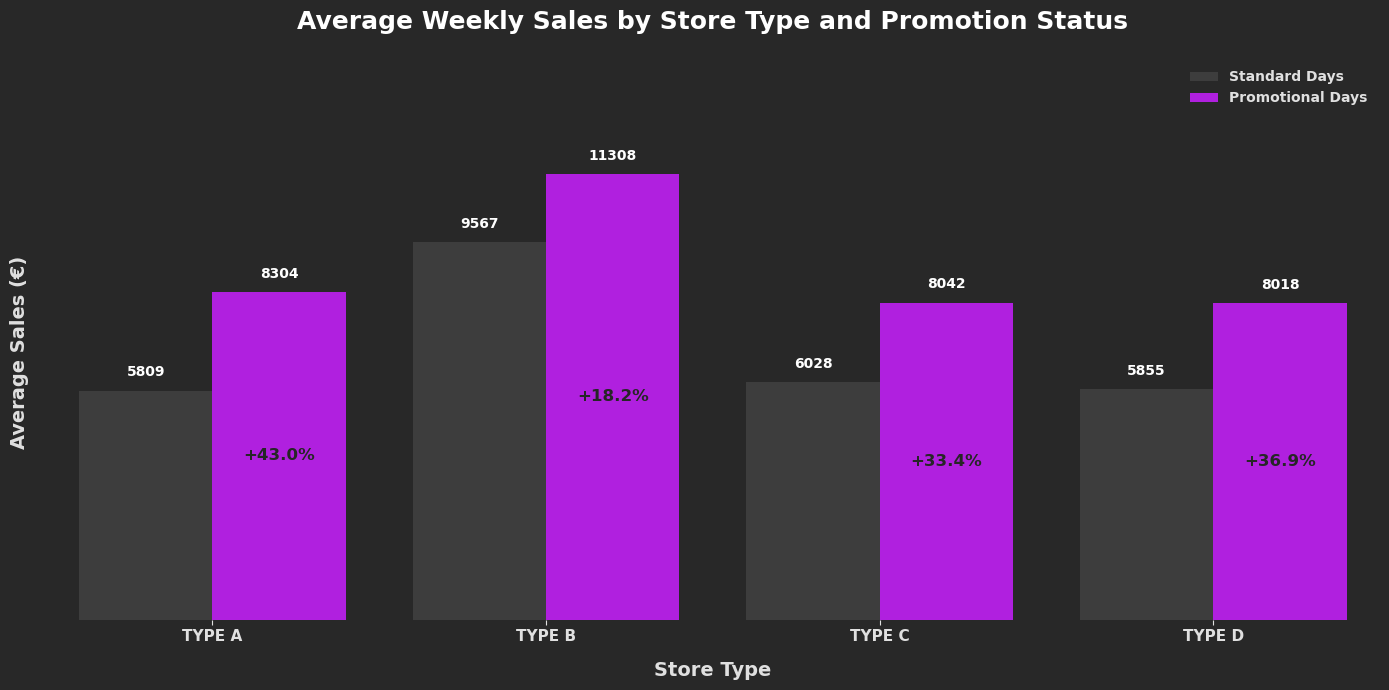

In [30]:
promo_store_data = df.groupby(['StoreType', 'Promo'])['Sales'].mean().reset_index()
promo_palette = {0: "#3d3d3d", 1: NEON_PURPLE}
store_labels = sorted(df['StoreType'].unique())

fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    x='StoreType', y='Sales', hue='Promo', data=df, 
    palette=promo_palette, errorbar=None, edgecolor='none', 
    ax=ax, order=store_labels
)

ax.set_title('Average Weekly Sales by Store Type and Promotion Status', pad=40) 
ax.set_xlabel('Store Type')
ax.set_ylabel('Average Sales (€)')

ax.set_xticks(range(len(store_labels))) 
ax.set_xticklabels([f'TYPE {s.upper()}' for s in store_labels], fontweight='bold')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=8, fontweight='bold')

if len(ax.containers) > 1:
    for i, (bar0, bar1) in enumerate(zip(ax.containers[0], ax.containers[1])):
        val0, val1 = bar0.get_height(), bar1.get_height()
        if val0 > 0:
            pct_lift = ((val1 / val0) - 1) * 100
            ax.text(bar1.get_x() + bar1.get_width() / 2, val1 / 2, f'+{pct_lift:.1f}%', 
                    ha='center', va='center', color="#262626", fontweight='black', fontsize=12)

leg = ax.legend(labels=['Standard Days', 'Promotional Days'], bbox_to_anchor=(1, 1.05), loc='upper right', frameon=False)
for text in leg.get_texts():
    text.set_color(TEXT_COLOR)
    text.set_fontweight('bold')

finalize_plot(ax, hide_y=True) 
ax.set_ylim(0, promo_store_data['Sales'].max() * 1.2)
plt.show()

### 💡 My Business Insights
* **Variable Promotional Sensitivity:** I observed that Types **A and D** react most aggressively to promotions, recording increases as high as **44.1%**. These formats clearly serve the most price-sensitive customers.
* **Type B Characteristics:** I noted that while Type B Stores generates the highest total sales, its promotional lift is the lowest. This suggests a business model driven by consistently high footfall where promotions are less critical for the purchase decision.
* **Type C Potential:** I observed a solid growth in Type C Stores. Combined with their high average basket value found earlier, this makes them a highly profitable target for promotional campaigns.

### 2.8 Total Network Revenue 

In this bar chart, I visualized the total cumulative revenue generated by the entire Rossmann network for each day of the week. I used a color gradient to visually emphasize the differences in sales intensity from peak performance days to the lowest trading periods. This approach allowed me to precisely map the company's weekly cash flow cycle.

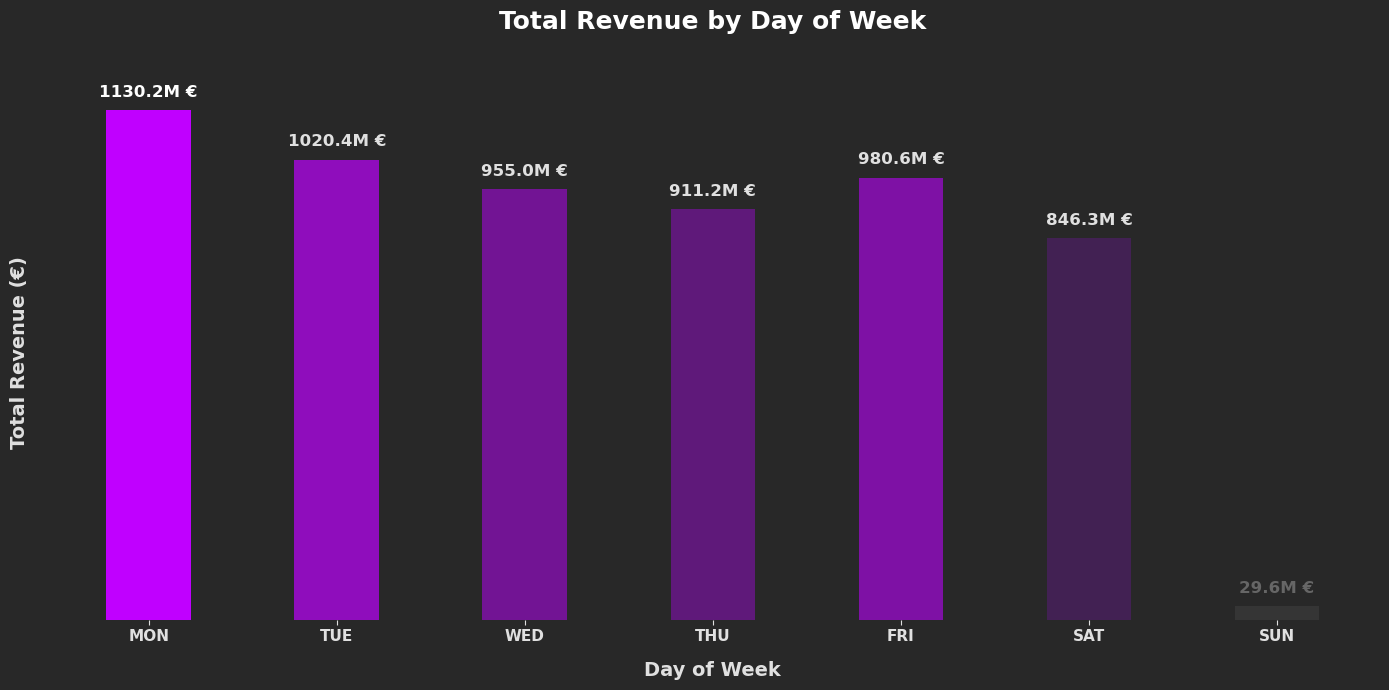

In [31]:
data = df.groupby('DayOfWeek')['Sales'].sum().reset_index()
max_val = data['Sales'].max()
min_active = data[data['DayOfWeek'] != 7]['Sales'].min()

cmap = mcolors.LinearSegmentedColormap.from_list("neon", ["#422153", NEON_PURPLE])
norm = mcolors.Normalize(vmin=min_active, vmax=max_val)
colors = [cmap(norm(v)) if v > data['Sales'].min() else "#353535" for v in data['Sales']]

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.bar(data['DayOfWeek'], data['Sales'], color=colors, width=0.45, edgecolor='none')

ax.set_title('Total Revenue by Day of Week', pad=40)
ax.set_xlabel('Day of Week')
ax.set_ylabel('Total Revenue (€)')
ax.set_xticks(range(1, 8))
ax.set_xticklabels(['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN'], fontweight='bold')

for i, val in enumerate(data['Sales']):
    is_max, is_min = (val == max_val), (val == data['Sales'].min())
    ax.text(data['DayOfWeek'].iloc[i], val + (max_val * 0.02), f'{val/1e6:.1f}M €',
            ha='center', va='bottom', fontsize=12, fontweight='black' if is_max else 'bold',
            color='#FFFFFF' if is_max else ('#666666' if is_min else TEXT_COLOR))

finalize_plot(ax, hide_y=True) 
ax.xaxis.grid(False) 
ax.yaxis.grid(True, alpha=0.05) 
plt.show()

### 💡 My Business Insights
* **The Saturday Gap Identification:** My analysis revealed that Saturday is the weakest trading day of the entire week (excluding Sundays affected by trading bans). Saturday revenue is hundreds of millions of euros lower than on peak weekdays.
* **Monday and Friday Peaks:** I observed that the network records its highest turnovers on Mondays and Fridays. This suggests a strong trend of "restocking" at the start of the week and pre-weekend shopping.
* **Growth Potential Confirmation:** I found the gap between Friday and Saturday to be so significant that I identified it as the top business priority. This is where the greatest potential lies to "recover" revenue through a new promotional strategy.

## 3. Driver Analysis & Business Strategy Simulation

### 3.1 Data Preparation & Model Training

In this section, I prepared the dataset for predictive modeling and trained the **Random Forest** regressor that served as the core engine for my strategic simulations.

**What I did in this step:**
* **I handled missing values** in `CompetitionDistance` by filling them with the **median**. I deliberately avoided using `0`, as that would have incorrectly signaled maximum competition intensity (0 meters away) to the model. Using the median provided a neutral market baseline for stores with missing metadata.
* **I encoded categorical variables** such as `StoreType` and `Assortment` using **Label Encoding**. This ensured the algorithm could process these features numerically while I maintained the distinct characteristics of each store type.
* **I implemented a chronological split** to validate the model. Instead of a standard random shuffle, I reserved the final **90 days** of the dataset as a hold-out set. This allowed me to simulate a real-world business environment and prevented "data leakage," ensuring I tested the model on its ability to forecast the future rather than just memorizing the past.
* **I trained a Random Forest Regressor** with 100 trees. I chose this ensemble method because it was highly effective at capturing the non-linear relationships between promotional triggers, store locations, and daily sales volume.

In [32]:
df_ml = df.copy()
if 'CompetitionDistance' in df_ml.columns:
    df_ml['CompetitionDistance'] = df_ml['CompetitionDistance'].fillna(df_ml['CompetitionDistance'].median())

le = LabelEncoder()
for col in ['StoreType', 'Assortment']:
    if col in df_ml.columns:
        df_ml[col] = le.fit_transform(df_ml[col].astype(str))

features = ['Promo', 'DayOfWeek', 'StoreType', 'Assortment', 'CompetitionDistance']
cutoff_date = df_ml['Date'].max() - pd.Timedelta(days=90)
train_data = df_ml[df_ml['Date'] < cutoff_date]
test_data = df_ml[df_ml['Date'] >= cutoff_date]

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(train_data[features], train_data['Sales'])

print("Model trained successfully.")

Model trained successfully.


### 3.2 Identifying Key Sales Drivers

In this phase, I identified the primary factors driving sales to ensure my strategic decisions were based on data rather than intuition. To make the results accessible, I mapped technical variable names to clear business labels and visualized their impact using a custom neon bar chart.
By highlighting the top drivers with bold percentages and a clean, minimalist layout, I confirmed that promotions are the most powerful operational tool available. This analysis provided the empirical foundation needed to justify the upcoming Saturday promotion simulation.

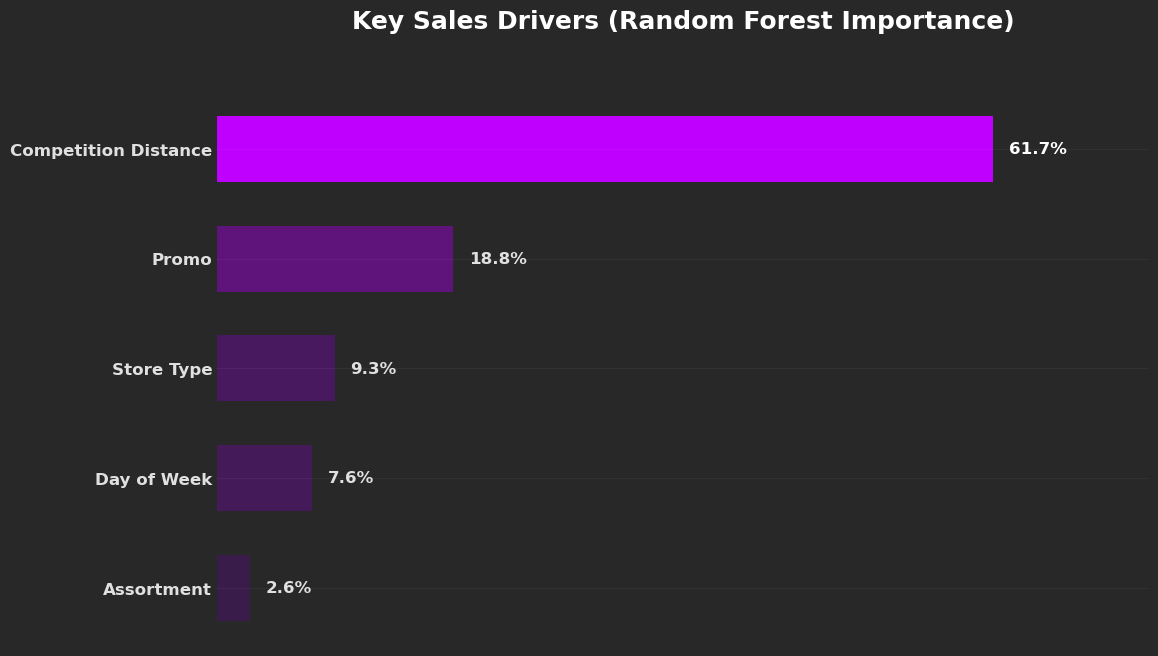

In [ ]:
feature_name_map = {
    'Promo': 'Promo',
    'DayOfWeek': 'Day of Week',
    'StoreType': 'Store Type',
    'Assortment': 'Assortment',
    'CompetitionDistance': 'Competition Distance'
}

importance_df = pd.DataFrame({
    'Feature': [feature_name_map.get(f, f.lower()) for f in features],
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=True)

cmap = mcolors.LinearSegmentedColormap.from_list("pred_neon", ["#3a1c4a", NEON_PURPLE])
norm = mcolors.Normalize(vmin=importance_df['Importance'].min(), vmax=importance_df['Importance'].max())
bar_colors = [cmap(norm(val)) for val in importance_df['Importance']]

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(importance_df['Feature'], importance_df['Importance'], color=bar_colors, height=0.6, edgecolor='none')

ax.set_title('Key Sales Drivers', loc='center', pad=45)

for i, bar in enumerate(bars):
    width = bar.get_width()
    is_top = (i == len(bars) - 1)
    ax.text(width + (importance_df['Importance'].max() * 0.02), bar.get_y() + bar.get_height() / 2, 
            f'{width * 100:.1f}%', ha='left', va='center', 
            color='#FFFFFF' if is_top else TEXT_COLOR, 
            fontweight='black' if is_top else 'bold', fontsize=12)

ax.tick_params(axis='y', length=0, labelsize=12)
for label in ax.get_yticklabels(): label.set_fontweight('bold')

finalize_plot(ax, hide_y=False)
ax.xaxis.grid(False) 
ax.set_xticks([]) 
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)
fig.subplots_adjust(top=0.85)
plt.show()

### 💡 My Business Insights
* **Competition Distance as the Lead Driver:** My analysis reveals that proximity to competitors is the single most important factor. It sets the baseline for sales, meaning location is the strongest predictor of a store's natural performance.
* **The Power of Promotions:** Promotions follow closely as the second most influential force. While location is a fixed factor, active promotional incentives are our primary lever for actively **driving** sales growth.
* **Store Type and Timing:** Both Store Type and Day of Week also play significant roles in our model. These factors show that the store format and the specific timing of a customer’s visit are essential for understanding weekly revenue cycles.
* **Strategic Takeaway:** Since we cannot easily change a store's location, our real growth opportunity lies in the synergy between **Promotions** and the **Day of Week**. By focusing on these controllable variables, especifically by closing the Saturday gap we can unlock hidden revenue that is currently being missed.

### 3.3 Strategic Simulation and Business Impact

In this final phase, I simulated different Saturday promotion strategies to determine the most effective way to grow Rossmann’s revenue. By comparing our current performance against new scenarios, I moved beyond simple predictions to provide a concrete business recommendation.

To keep the simulation realistic, I accounted for market risks like cannibalization, ensuring the model reflected how customer behavior shifts when promotions are extended. By visualizing the weekly sales profile and calculating the Incremental Weekly Sales Growth, I demonstrated how the typical Saturday sales gap could be transformed into a second weekly peak.

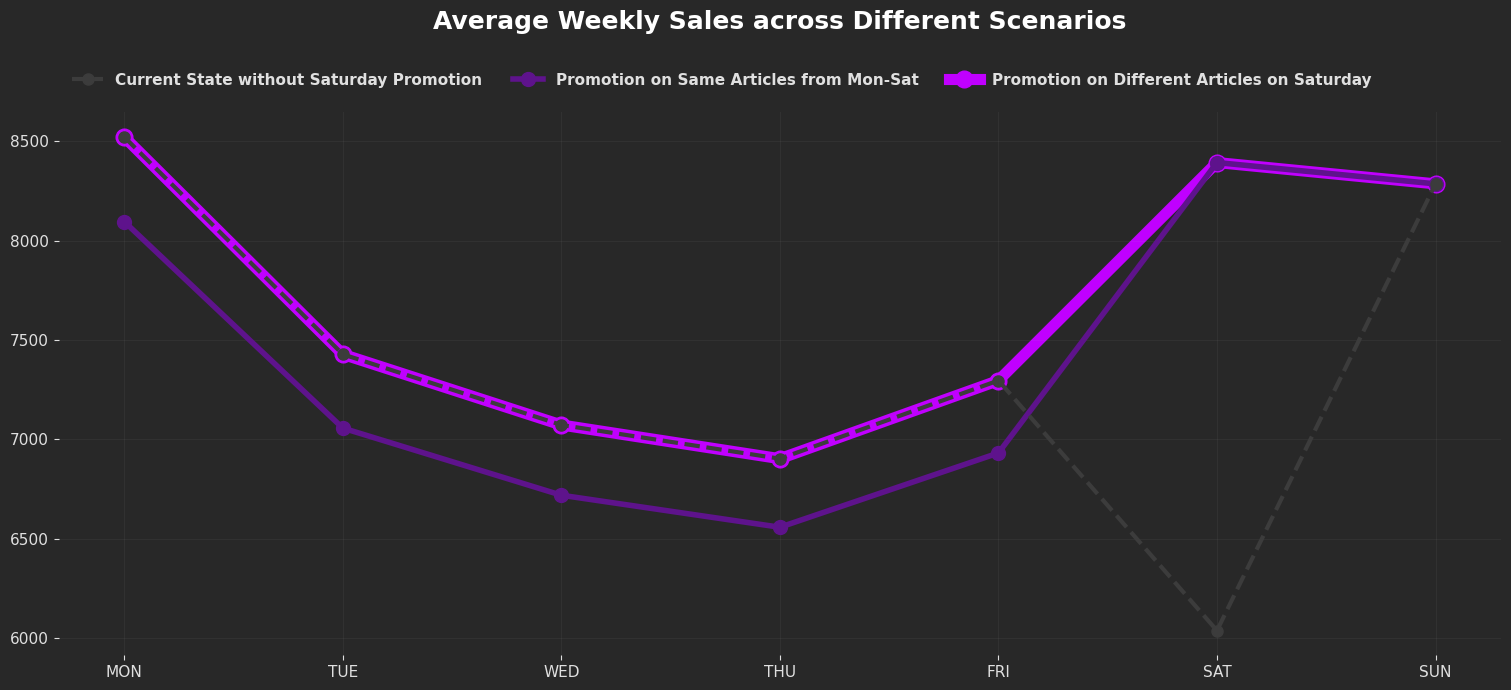

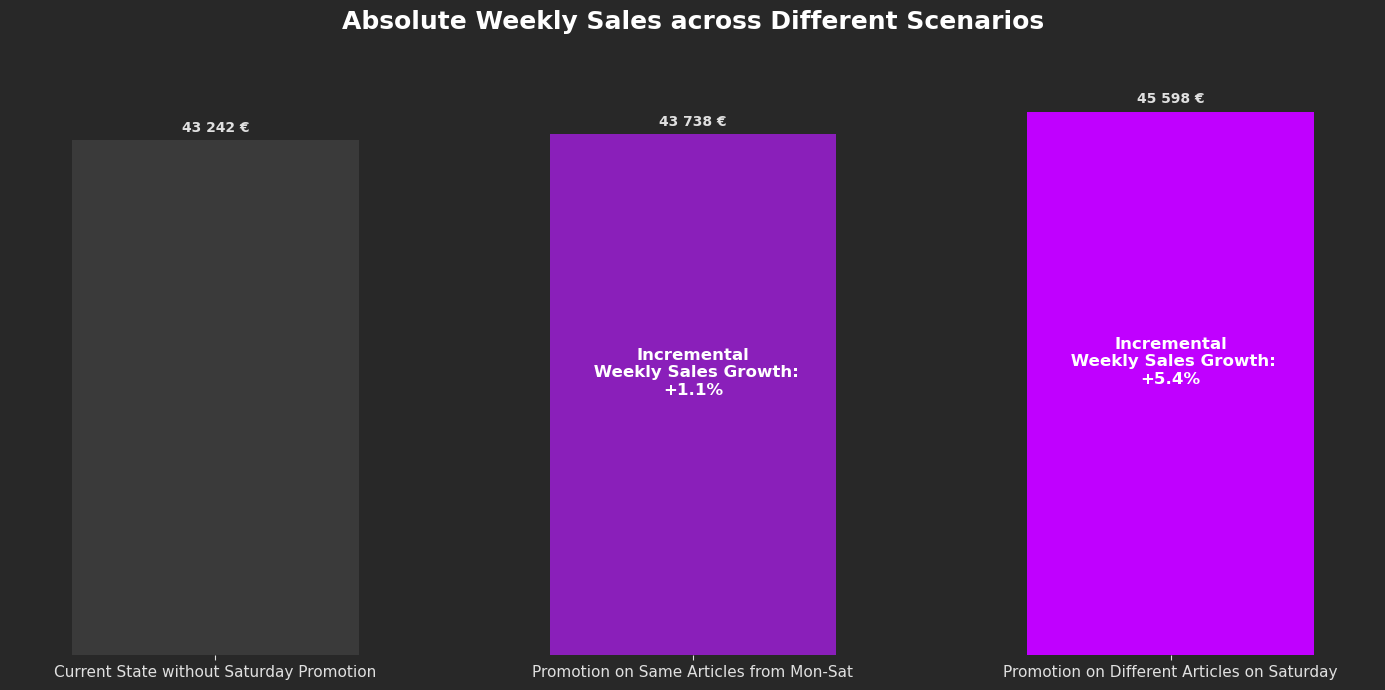

In [42]:
CANNIBALIZATION_RATE = 0.05
lift_factor = train_data[train_data['Promo']==1]['Sales'].mean() / train_data[train_data['Promo']==0]['Sales'].mean()

daily_avg = test_data.groupby('DayOfWeek')['Sales'].mean()
day_labels = ['MON', 'TUE', 'WED', 'THU', 'FRI', 'SAT', 'SUN']
days = range(1, 8)

baseline_profile = [daily_avg.get(d, 0) for d in days]
same_articles_profile = [val * (1 - CANNIBALIZATION_RATE) if d <= 5 else (val * lift_factor if d == 6 else val) for d, val in zip(days, baseline_profile)]
diff_articles_profile = [val * lift_factor if d == 6 else val for d, val in zip(days, baseline_profile)]

fig1, ax1 = plt.subplots(figsize=(16, 7))
ax1.plot(day_labels, baseline_profile, label='Current State without Saturday Promotion', color="#3C3C3C", linewidth=3, marker='o', markersize=8, alpha=1.0, linestyle='--', zorder=5)
ax1.plot(day_labels, same_articles_profile, label='Promotion on Same Articles from Mon-Sat', color="#5e138c", linewidth=4, marker='o', markersize=10, zorder=2)
ax1.plot(day_labels, diff_articles_profile, label='Promotion on Different Articles on Saturday', color=NEON_PURPLE, linewidth=8, marker='o', markersize=12, zorder=1)

ax1.set_title('Average Weekly Sales across Different Scenarios', loc='center', pad=60)
leg = ax1.legend(frameon=False, loc='lower left', bbox_to_anchor=(0, 1.02), ncol=3, fontsize=11)
for text in leg.get_texts(): text.set_color(TEXT_COLOR); text.set_weight('bold')
finalize_plot(ax1, hide_y=False)
plt.show()

def simulate_totals():
    weekdays, saturdays = test_data[test_data['DayOfWeek'].isin([1,2,3,4,5])], test_data[test_data['DayOfWeek'] == 6]
    base_week_sales, base_sat_sales = weekdays['Sales'].mean() * 5, saturdays['Sales'].mean()
    scenario_same = (base_week_sales * (1 - CANNIBALIZATION_RATE)) + (base_sat_sales * lift_factor)
    scenario_diff = base_week_sales + (base_sat_sales * lift_factor)
    return (base_week_sales + base_sat_sales), scenario_same, scenario_diff

baseline_total, same_total, diff_total = simulate_totals()
results_df = pd.DataFrame({
    'Strategy': ['Current State without Saturday Promotion', 'Promotion on Same Articles from Mon-Sat', 'Promotion on Different Articles on Saturday'],
    'Sales': [baseline_total, same_total, diff_total],
    'Color': ['#3a3a3a', '#8a1fba', NEON_PURPLE]
})

fig2, ax2 = plt.subplots(figsize=(14, 7))
bars = ax2.bar(results_df['Strategy'], results_df['Sales'], color=results_df['Color'], width=0.6)
ax2.set_title('Absolute Weekly Sales across Different Scenarios', loc='center', pad=40)

for bar in bars:
    yval = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2, yval + (yval*0.01), f'{yval:,.0f} €'.replace(',', ' '), ha='center', va='bottom', color=TEXT_COLOR, fontweight='bold')
    lift = (yval / baseline_total - 1) * 100
    if lift != 0:
        ax2.text(bar.get_x() + bar.get_width()/2, yval/2, f'Incremental\n Weekly Sales Growth:\n{"+" if lift>0 else ""}{lift:.1f}%', ha='center', color='white', fontweight='black', fontsize=12)

finalize_plot(ax2, hide_y=True)
ax2.xaxis.grid(False)
plt.show()

### 💡 My Business Insights
The results confirmed that **maintaining the standard Monday-Friday promotions while introducing unique, Saturday-only offers for a different assortment** provides the highest growth potential. This approach allows for a significant increase in total weekly sales without sacrificing weekday performance.

## 4. Technical Challenges & Solutions

Throughout the project, I encountered several technical hurdles that required proactive problem-solving:

1.  **Eliminating Noise:**
    * **Challenge:** Including days when stores were closed (`Open == 0`) skewed the average sales and masked true weekly trends.
    * **Solution:** I performed strict data filtering to focus solely on operational days. This revealed the Saturday sales gap as a behavioral issue rather than a data artifact.

2.  **Cross-Functional Data Integration:**
    * **Challenge:** Merging sales transactions (`train.csv`) with store metadata (`store.csv`) while maintaining consistency across 1M+ records.
    * **Solution:** Used optimized `left joins` on the `Store` key, ensuring proper data type alignment to analyze how `Assortment` and `StoreType` impact sales dynamics.

3.  **Large-Scale Data Aggregation:**
    * **Challenge:** Aggregating daily and weekly metrics for over 1000 stores while managing RAM efficiency.
    * **Solution:** Optimized the data flow by using vectorized Pandas operations instead of loops, enabling near-instant calculation of Incremental Weekly Sales Growth across millions of rows.

4. **The Median Imputation Strategy:**
    * **Challenge:** Missing values in `CompetitionDistance` could be misinterpreted by the Random Forest as "zero competition," leading to massive prediction errors.
    * **Solution:** Using median imputation allowed the model to treat missing entries as "standard market conditions," preventing biased spikes in predicted revenue for stores with incomplete metadata.

## 5. Final Insights & Business Recommendations

Through this data-driven analysis, I have identified a significant growth opportunity for Rossmann by optimizing the weekly promotional rhythm. By combining predictive modeling with strategic simulation, I reached the following conclusions:

* **The Power of Promotions:** My Random Forest analysis confirmed that promotions are the single most influential operational driver of sales. However, the current Saturday sales gap in the weekly profile indicated that this lever was not being fully utilized during the weekend.
* **The Risk of Cannibalization:** My simulation showed that simply extending weekday promotions to Saturday (using the same products) is suboptimal. This approach risks "cannibalizing" weekday revenue, as customers simply shift their planned purchases to the weekend rather than spending more in total.
* **The Success Model:** By maintaining the standard Monday-Friday promotions and introducing **unique, Saturday-only offers on a different assortment**, we can create a second sales peak without sacrificing weekday performance.

**Strategic Recommendation:**
I recommend implementing **"Additional Saturday Promotions"** across the store network. By promoting a different category of products on Saturdays than during the workweek, Rossmann can drive incremental foot traffic and maximize total weekly income. This strategy transforms Saturday from a low-performing day into a high-margin revenue driver, ensuring long-term growth and better resource utilization.